# 06 — Network Analysis

This notebook converts similarity and association tables into networks.

It adds the course component on graph theory and network metrics: nodes, edges, centrality, and communities.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis")
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_DIR / "output"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
DOCS_DIR = PROJECT_DIR / "docs"
POSTER_DIR = PROJECT_DIR / "poster"

for folder in [PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, DOCS_DIR, POSTER_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.chdir(NOTEBOOK_DIR)
print("Project directory:", PROJECT_DIR)
print("Current folder:", os.getcwd())


!pip -q install pandas matplotlib networkx

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

Mounted at /content/drive
Project directory: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis
Current folder: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/notebooks


## 2. Genre similarity network

In [2]:
similarity_df = pd.read_csv(TABLES_DIR / "genre_cosine_similarity.csv", index_col=0)
similarity_df

,Law,Narrative,Poetry_Wisdom,Prophecy
Law,1.000000,0.416679,0.401122,0.455519
Narrative,0.416679,1.000000,0.444826,0.685129
Poetry_Wisdom,0.401122,0.444826,1.000000,0.533963
Prophecy,0.455519,0.685129,0.533963,1.000000


In [3]:
GENRE_SIMILARITY_THRESHOLD = 0.15

G_genre = nx.Graph()

for genre in similarity_df.index:
    G_genre.add_node(genre, node_type="genre")

for i, source in enumerate(similarity_df.index):
    for j, target in enumerate(similarity_df.columns):
        if i < j:
            weight = float(similarity_df.loc[source, target])
            if weight >= GENRE_SIMILARITY_THRESHOLD:
                G_genre.add_edge(source, target, weight=weight)

print("Genre network nodes:", G_genre.number_of_nodes())
print("Genre network edges:", G_genre.number_of_edges())

genre_edges = nx.to_pandas_edgelist(G_genre)
genre_edges.to_csv(TABLES_DIR / "genre_similarity_network_edges.csv", index=False)

centrality = pd.DataFrame({
    "node": list(G_genre.nodes()),
    "degree": [G_genre.degree(n) for n in G_genre.nodes()],
    "degree_centrality": [nx.degree_centrality(G_genre).get(n, 0) for n in G_genre.nodes()],
    "betweenness_centrality": [nx.betweenness_centrality(G_genre, weight="weight").get(n, 0) for n in G_genre.nodes()],
})

centrality.to_csv(TABLES_DIR / "genre_network_centrality.csv", index=False)
centrality

Genre network nodes: 4
Genre network edges: 6


,node,degree,degree_centrality,betweenness_centrality
0,Law,3,1.0,0.0
1,Narrative,3,1.0,0.0
2,Poetry_Wisdom,3,1.0,0.0
3,Prophecy,3,1.0,0.0


## 3. Visualize genre similarity network

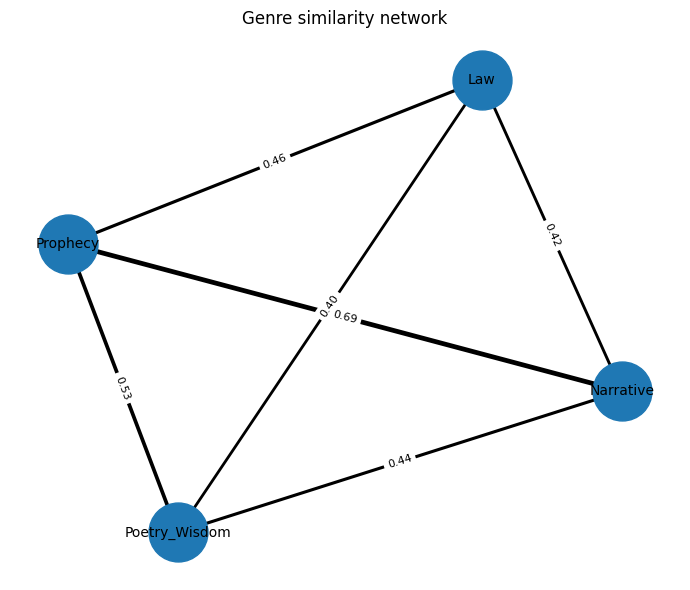

Saved: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/output/figures/genre_similarity_network.png


In [4]:
plt.figure(figsize=(7, 6))

pos = nx.spring_layout(G_genre, seed=42, weight="weight")
weights = [G_genre[u][v]["weight"] * 5 for u, v in G_genre.edges()]

nx.draw_networkx_nodes(G_genre, pos, node_size=1800)
nx.draw_networkx_labels(G_genre, pos, font_size=10)
nx.draw_networkx_edges(G_genre, pos, width=weights)

edge_labels = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G_genre.edges(data=True)}
nx.draw_networkx_edge_labels(G_genre, pos, edge_labels=edge_labels, font_size=8)

plt.title("Genre similarity network")
plt.axis("off")
plt.tight_layout()

filename = FIGURES_DIR / "genre_similarity_network.png"
plt.savefig(filename, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", filename)

## 4. Word association network from PMI

In [5]:
pmi_path = TABLES_DIR / "pmi_word_associations.csv"
pmi_df = pd.read_csv(pmi_path)

# Keep a readable, interpretable subset.
TOP_PAIRS_PER_GENRE = 20
word_network_rows = (
    pmi_df
    .sort_values(["genre", "pmi"], ascending=[True, False])
    .groupby("genre")
    .head(TOP_PAIRS_PER_GENRE)
    .reset_index(drop=True)
)

G_words = nx.Graph()

for _, row in word_network_rows.iterrows():
    w1, w2 = row["word1"], row["word2"]
    genre = row["genre"]
    weight = float(row["pmi"])

    G_words.add_node(w1, node_type="lexeme")
    G_words.add_node(w2, node_type="lexeme")

    if G_words.has_edge(w1, w2):
        G_words[w1][w2]["weight"] = max(G_words[w1][w2]["weight"], weight)
        G_words[w1][w2]["genres"] += f";{genre}"
    else:
        G_words.add_edge(w1, w2, weight=weight, genres=genre)

print("Word network nodes:", G_words.number_of_nodes())
print("Word network edges:", G_words.number_of_edges())

word_edges = nx.to_pandas_edgelist(G_words)
word_edges.to_csv(TABLES_DIR / "word_association_network_edges.csv", index=False)

word_centrality = pd.DataFrame({
    "node": list(G_words.nodes()),
    "degree": [G_words.degree(n) for n in G_words.nodes()],
    "degree_centrality": [nx.degree_centrality(G_words).get(n, 0) for n in G_words.nodes()],
    "betweenness_centrality": [nx.betweenness_centrality(G_words, weight="weight").get(n, 0) for n in G_words.nodes()],
})

try:
    eigen = nx.eigenvector_centrality(G_words, max_iter=1000, weight="weight")
except nx.PowerIterationFailedConvergence:
    eigen = {n: np.nan for n in G_words.nodes()}

word_centrality["eigenvector_centrality"] = word_centrality["node"].map(eigen)
word_centrality = word_centrality.sort_values("degree_centrality", ascending=False)
word_centrality.to_csv(TABLES_DIR / "word_network_centrality.csv", index=False)

word_centrality.head(20)

Word network nodes: 106
Word network edges: 80


,node,degree,degree_centrality,betweenness_centrality,eigenvector_centrality
0,JTRT/,5,0.047619,0.001648,4.638693e-01
1,KBD=/,5,0.047619,0.001648,4.638693e-01
2,KLJH/,4,0.038095,0.000000,4.279517e-01
3,KSL=/,4,0.038095,0.000000,4.279517e-01
8,CNJM/,4,0.038095,0.000000,3.958990e-01
6,>MH/,4,0.038095,0.001099,4.839116e-09
21,XWY/,4,0.038095,0.003114,1.551022e-02
25,MR>H/,4,0.038095,0.001099,3.811658e-05
22,BFR/,3,0.028571,0.000000,3.564931e-05
17,SWR[,3,0.028571,0.004579,2.092376e-01


## 5. Visualize word association network

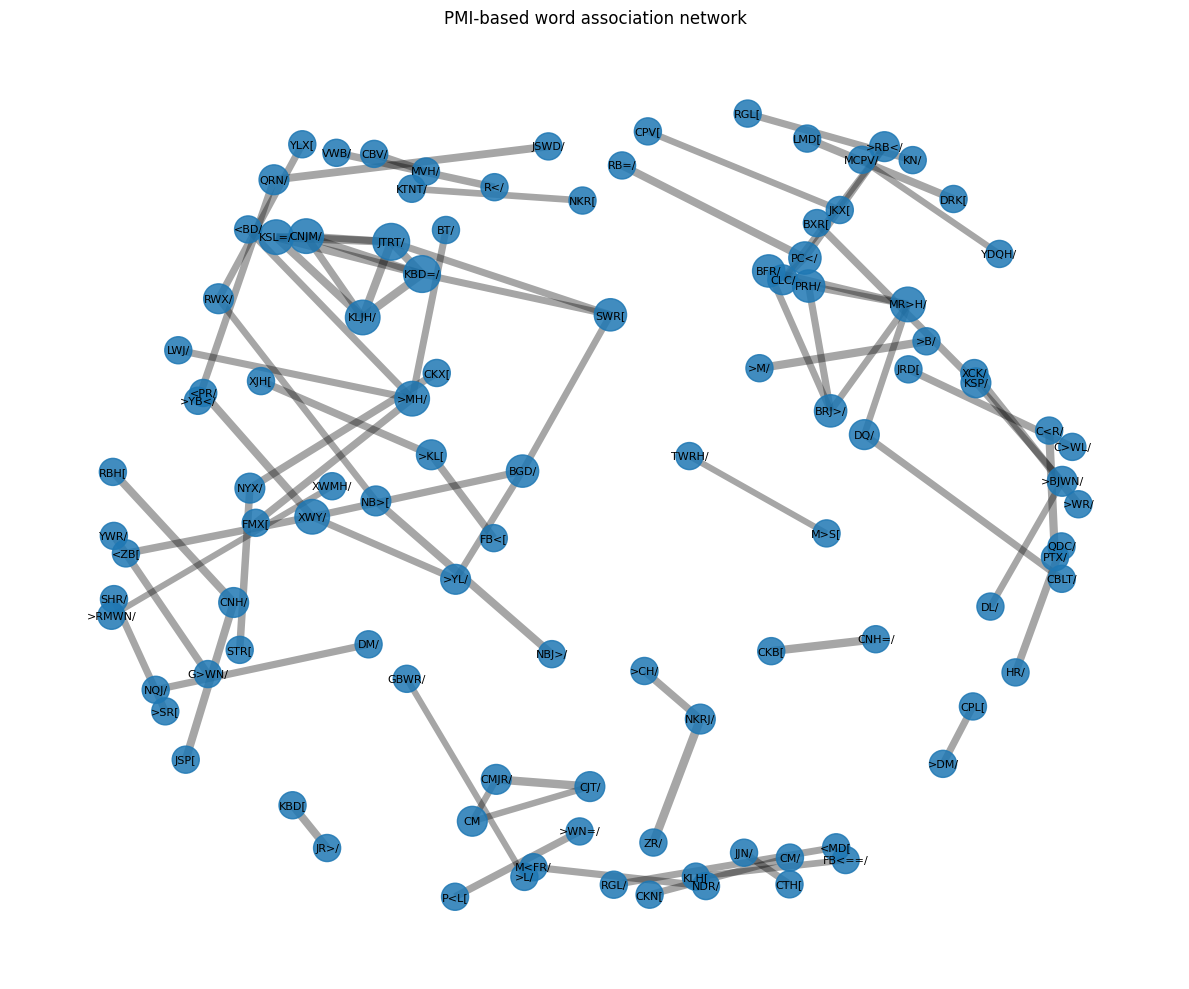

Saved: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/output/figures/word_association_network.png


In [6]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G_words, seed=42, k=0.8, weight="weight")
node_sizes = [300 + 80 * G_words.degree(n) for n in G_words.nodes()]
edge_widths = [max(0.5, G_words[u][v]["weight"]) for u, v in G_words.edges()]

nx.draw_networkx_nodes(G_words, pos, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G_words, pos, width=edge_widths, alpha=0.35)
nx.draw_networkx_labels(G_words, pos, font_size=8)

plt.title("PMI-based word association network")
plt.axis("off")
plt.tight_layout()

filename = FIGURES_DIR / "word_association_network.png"
plt.savefig(filename, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", filename)

## 6. Network interpretation

The genre network represents similarity between genre-level lexical profiles. The word network represents strong PMI-based lexical associations.

Central nodes may be interpreted as lexical hubs, while high-betweenness nodes may function as bridges between clusters of associated words. Because the project is a pilot study, these metrics are exploratory and should be interpreted together with close reading and philological judgment.